# 🗑️ Garbage Classification AI System
### YOLOv8 Classification + Streamlit + ngrok

---
**Sections:**
1. GPU Check
2. Mount Google Drive
3. Verify Dataset
4. Install Dependencies
5. Train YOLOv8 Classification Model
6. Save Trained Model
7. Test Model
8. Create Streamlit App
9. Configure ngrok
10. Launch Application
---

## 🔷 SECTION 1 — GPU CHECK

In [ ]:
# ============================================================
# SECTION 1: GPU CHECK
# Detect CUDA/GPU availability and display GPU information
# ============================================================

import subprocess
import sys

print("=" * 60)
print("           GARBAGE CLASSIFICATION AI SYSTEM")
print("         YOLOv8 + Streamlit + ngrok Pipeline")
print("=" * 60)
print()

# Check GPU availability
print("[1/10] Checking GPU availability...")
print("-" * 40)

try:
    result = subprocess.run(
        ['nvidia-smi'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print("✅ GPU DETECTED!")
        print(result.stdout)
    else:
        print("⚠️  No GPU detected. Training will use CPU (slower).")
except FileNotFoundError:
    print("⚠️  nvidia-smi not found. Running on CPU.")

# Check PyTorch CUDA
try:
    import torch
    print(f"\nPyTorch version : {torch.__version__}")
    print(f"CUDA available  : {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU Name        : {torch.cuda.get_device_name(0)}")
        print(f"GPU Memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
        print(f"CUDA Version    : {torch.version.cuda}")
except ImportError:
    print("PyTorch not yet installed (will be installed in Section 4).")

print()
print("✅ Section 1 Complete")

           GARBAGE CLASSIFICATION AI SYSTEM
         YOLOv8 + Streamlit + ngrok Pipeline

[1/10] Checking GPU availability...
----------------------------------------
✅ GPU DETECTED!
Sat May 23 11:05:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |      

## 🔷 SECTION 2 — MOUNT GOOGLE DRIVE

In [ ]:
# ============================================================
# SECTION 2: MOUNT GOOGLE DRIVE
# Mount Drive to access the dataset and save the model
# ============================================================

print("[2/10] Mounting Google Drive...")
print("-" * 40)

from google.colab import drive
drive.mount('/content/drive')

import os

# Define key paths
DATASET_PATH = "/content/drive/MyDrive/project computer vision/datasert-resized"
MODEL_SAVE_PATH = "/content/drive/MyDrive/project computer vision/best.pt"
LOCAL_MODEL_PATH = "/content/best.pt"
APP_PATH = "/content/app.py"

print(f"\nDataset path    : {DATASET_PATH}")
print(f"Model save path : {MODEL_SAVE_PATH}")
print(f"App path        : {APP_PATH}")
print()
print("✅ Section 2 Complete")

[2/10] Mounting Google Drive...
----------------------------------------
Mounted at /content/drive

Dataset path    : /content/drive/MyDrive/project computer vision/datasert-resized
Model save path : /content/drive/MyDrive/project computer vision/best.pt
App path        : /content/app.py

✅ Section 2 Complete


## 🔷 SECTION 3 — VERIFY DATASET

[3/10] Verifying dataset...
----------------------------------------
✅ Dataset found at: /content/drive/MyDrive/project computer vision/dataset-resized

📦 Number of classes : 6
📁 Classes found     : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

📊 Image count per class:
------------------------------
  cardboard      :   403 images
  glass          :   501 images
  metal          :   410 images
  paper          :   594 images
  plastic        :   482 images
  trash          :   137 images
------------------------------
  TOTAL          :  2527 images

🖼️  Displaying sample images...


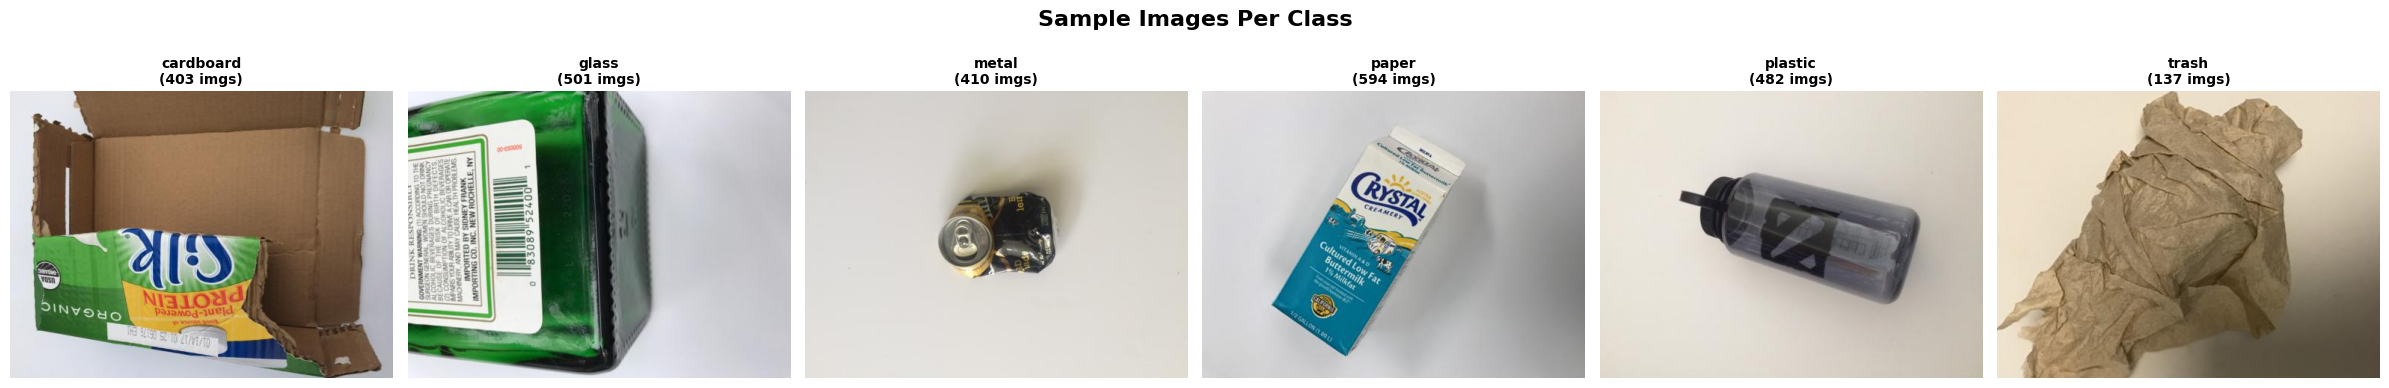

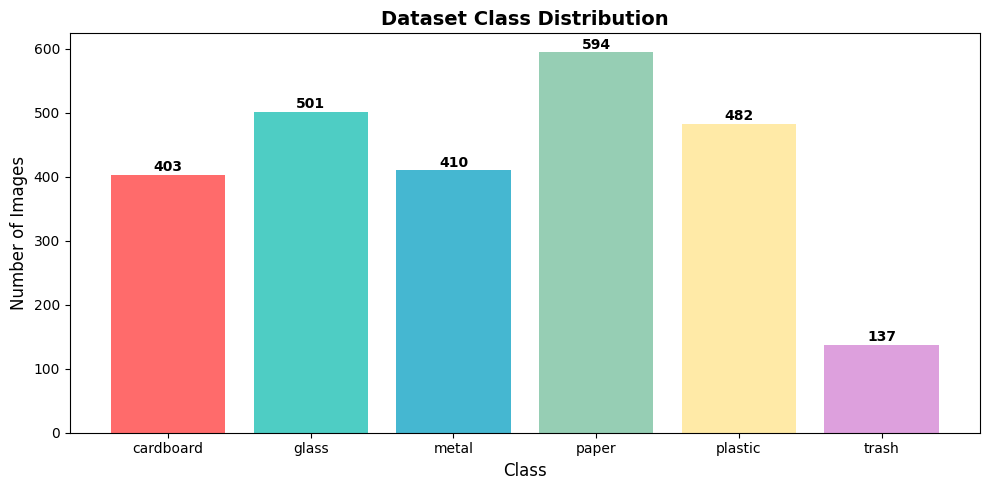

✅ Section 3 Complete


In [ ]:
# ============================================================
# SECTION 3: VERIFY DATASET
# Check dataset structure, count images, show samples
# ============================================================

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

print("[3/10] Verifying dataset...")
print("-" * 40)

DATASET_PATH = "/content/drive/MyDrive/project computer vision/dataset-resized"

# Check dataset exists
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f"\n❌ Dataset not found at: {DATASET_PATH}\n"
        "Please verify that the path in Google Drive is correct."
    )

print(f"✅ Dataset found at: {DATASET_PATH}")
print()

# Discover classes (subfolders)
classes = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

print(f"📦 Number of classes : {len(classes)}")
print(f"📁 Classes found     : {classes}")
print()

# Count images per class
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff'}
class_counts = {}
total_images = 0
sample_images = {}  # Store one sample per class for display

print("📊 Image count per class:")
print("-" * 30)

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    images = [
        f for f in os.listdir(cls_path)
        if Path(f).suffix.lower() in VALID_EXTENSIONS
    ]
    class_counts[cls] = len(images)
    total_images += len(images)
    if images:
        sample_images[cls] = os.path.join(cls_path, images[0])
    print(f"  {cls:<15}: {len(images):>5} images")

print("-" * 30)
print(f"  {'TOTAL':<15}: {total_images:>5} images")
print()

# Display sample images from each class
print("🖼️  Displaying sample images...")
n = len(sample_images)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
fig.suptitle('Sample Images Per Class', fontsize=16, fontweight='bold', y=1.02)

if n == 1:
    axes = [axes]

for ax, (cls, img_path) in zip(axes, sample_images.items()):
    try:
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(f"{cls}\n({class_counts[cls]} imgs)", fontsize=10, fontweight='bold')
        ax.axis('off')
    except Exception as e:
        ax.text(0.5, 0.5, f"Error\n{cls}", ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.savefig('/content/dataset_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print()

# Bar chart of class distribution
fig2, ax2 = plt.subplots(figsize=(10, 5))
bars = ax2.bar(class_counts.keys(), class_counts.values(),
               color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD'])
ax2.set_title('Dataset Class Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Class', fontsize=12)
ax2.set_ylabel('Number of Images', fontsize=12)
for bar, (cls, cnt) in zip(bars, class_counts.items()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(cnt), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Section 3 Complete")

## 🔷 SECTION 4 — INSTALL DEPENDENCIES

In [ ]:
# ============================================================
# SECTION 4: INSTALL DEPENDENCIES
# Install all required packages
# ============================================================

print("[4/10] Installing dependencies...")
print("-" * 40)

import subprocess
import sys

packages = [
    "ultralytics",
    "streamlit",
    "pyngrok",
    "opencv-python-headless",
    "pillow",
    "pandas",
    "numpy",
    "matplotlib",
    "plotly",
]

for pkg in packages:
    print(f"  Installing {pkg}...", end=" ", flush=True)
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print("✅")
    else:
        print(f"⚠️  Warning: {result.stderr[:100]}")

print()

# Verify imports
print("Verifying installations...")
import_checks = [
    ("ultralytics", "ultralytics"),
    ("streamlit", "streamlit"),
    ("pyngrok", "pyngrok"),
    ("cv2", "opencv-python"),
    ("PIL", "Pillow"),
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("plotly", "plotly"),
]

for module, display_name in import_checks:
    try:
        __import__(module)
        print(f"  ✅ {display_name}")
    except ImportError:
        print(f"  ❌ {display_name} — FAILED")

print()
print("✅ Section 4 Complete")

[4/10] Installing dependencies...
----------------------------------------
  Installing ultralytics... ✅
  Installing streamlit... ✅
  Installing pyngrok... ✅
  Installing opencv-python-headless... ✅
  Installing pillow... ✅
  Installing pandas... ✅
  Installing numpy... ✅
  Installing matplotlib... ✅
  Installing plotly... ✅

Verifying installations...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  ✅ ultralytics
  ✅ streamlit
  ✅ pyngrok
  ✅ opencv-python
  ✅ Pillow
  ✅ pandas
  ✅ numpy
  ✅ matplotlib
  ✅ plotly

✅ Section 4 Complete


## 🔷 SECTION 5 — TRAIN YOLOv8 CLASSIFICATION MODEL

In [ ]:
# ============================================================
# SECTION 5: TRAIN YOLOv8 CLASSIFICATION MODEL
# Train on the garbage dataset using YOLOv8n-cls
# Expected time: ~10–20 minutes on Colab GPU
# ============================================================

from ultralytics import YOLO
import torch

print("[5/10] Training YOLOv8 classification model...")
print("-" * 40)
print(f"Device          : {'GPU - ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"Dataset         : {DATASET_PATH}")
print(f"Epochs          : 30")
print(f"Image size      : 224")
print(f"Batch size      : 32")
print("-" * 40)
print("Starting training... (estimated 10–20 minutes)")
print()

# Load YOLOv8 nano classification model
model = YOLO("yolov8n-cls.pt")

# Train the model
results = model.train(
    data="/content/drive/MyDrive/project computer vision/dataset-resized",
    epochs=30,
    imgsz=224,
    batch=32,
    device=0 if torch.cuda.is_available() else "cpu",
    project="/content/runs/classify",
    name="garbage_classifier",
    patience=10,         # Early stopping patience
    save=True,
    plots=True,
    verbose=True
)

print()
print("🎉 Training complete!")
print(f"Results saved to: /content/runs/classify/garbage_classifier")
print()
print("✅ Section 5 Complete")

[5/10] Training YOLOv8 classification model...
----------------------------------------
Device          : GPU - Tesla T4
Dataset         : /content/drive/MyDrive/project computer vision/dataset-resized
Epochs          : 30
Image size      : 224
Batch size      : 32
----------------------------------------
Starting training... (estimated 10–20 minutes)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/project computer vision/dataset-resized, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, f

## 🔷 SECTION 6 — SAVE TRAINED MODEL

[6/10] Saving trained model...
----------------------------------------
✅ Found best.pt at: /content/runs/classify/garbage_classifier/weights/best.pt
✅ Copied to local path: /content/best.pt
✅ Saved to Google Drive: /content/drive/MyDrive/project computer vision/best.pt

Model file size: 2.84 MB

Training artifacts saved at: /content/runs/classify/garbage_classifier


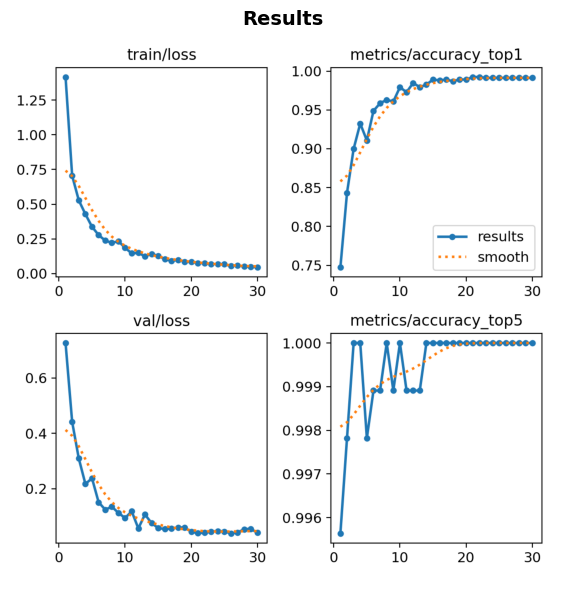

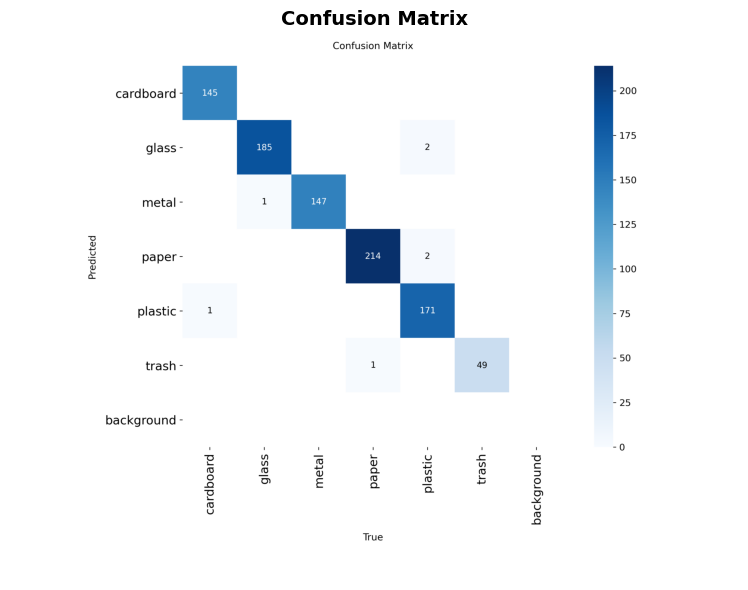


✅ Section 6 Complete


In [ ]:
# ============================================================
# SECTION 6: SAVE TRAINED MODEL
# Locate best.pt and copy it to Google Drive
# ============================================================

import os
import shutil
import glob

print("[6/10] Saving trained model...")
print("-" * 40)

# Locate the best.pt file from training
search_pattern = "/content/runs/classify/**/best.pt"
best_pt_files = glob.glob(search_pattern, recursive=True)

if not best_pt_files:
    raise FileNotFoundError(
        "❌ best.pt not found! Training may not have completed successfully.\n"
        f"Searched: {search_pattern}"
    )

best_pt_source = best_pt_files[0]
print(f"✅ Found best.pt at: {best_pt_source}")

# Copy to local /content/ for easy access
LOCAL_MODEL_PATH = "/content/best.pt"
shutil.copy2(best_pt_source, LOCAL_MODEL_PATH)
print(f"✅ Copied to local path: {LOCAL_MODEL_PATH}")

# Copy to Google Drive
DRIVE_SAVE_PATH = "/content/drive/MyDrive/project computer vision/best.pt"
os.makedirs(os.path.dirname(DRIVE_SAVE_PATH), exist_ok=True)
shutil.copy2(best_pt_source, DRIVE_SAVE_PATH)
print(f"✅ Saved to Google Drive: {DRIVE_SAVE_PATH}")

# Display file size
size_mb = os.path.getsize(LOCAL_MODEL_PATH) / (1024 * 1024)
print(f"\nModel file size: {size_mb:.2f} MB")

# Display training results if available
results_dir = os.path.dirname(best_pt_source).replace('/weights', '')
print(f"\nTraining artifacts saved at: {results_dir}")

# Show training plots if they exist
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for plot_name in ['results.png', 'confusion_matrix.png']:
    plot_path = os.path.join(results_dir, plot_name)
    if os.path.exists(plot_path):
        img = mpimg.imread(plot_path)
        plt.figure(figsize=(12, 6))
        plt.imshow(img)
        plt.title(plot_name.replace('.png', '').replace('_', ' ').title(),
                  fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

print()
print("✅ Section 6 Complete")

## 🔷 SECTION 7 — TEST MODEL

[7/10] Testing model with a sample image...
----------------------------------------
✅ Model loaded from: /content/best.pt
   Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

📤 Please upload a test image (JPG/PNG)...


Saving Various_products_made_from_paper.JPG to Various_products_made_from_paper.JPG

Running inference on: Various_products_made_from_paper.JPG

🏆 PREDICTION RESULT
   Predicted Class : PAPER
   Confidence      : 98.42%

📊 Top-5 Predictions:
  1. paper           98.42% ███████████████████
  2. cardboard        1.55% 
  3. trash            0.02% 
  4. plastic          0.01% 
  5. glass            0.01% 


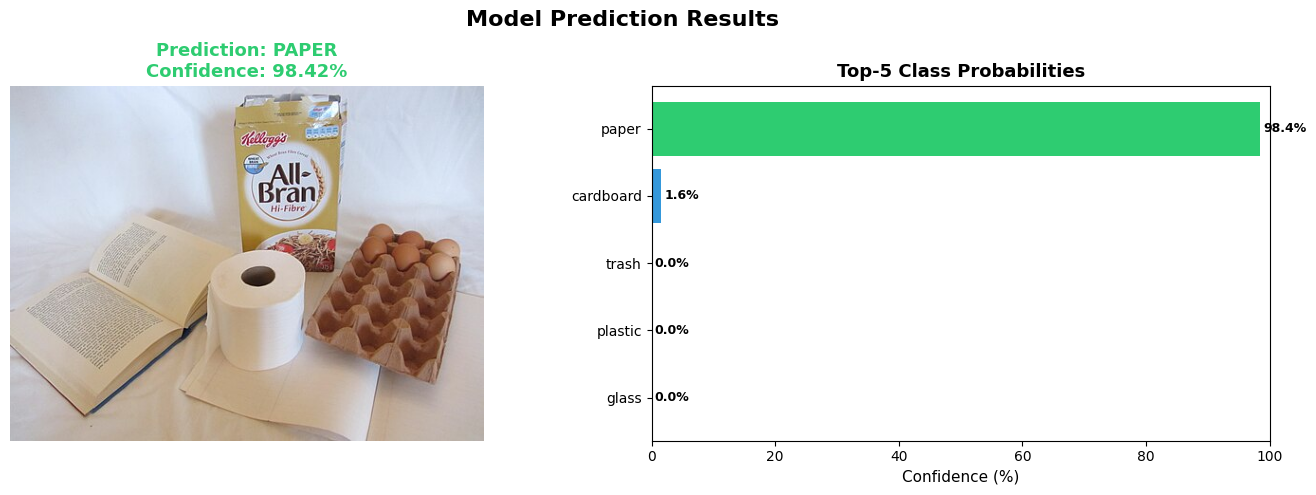


✅ Section 7 Complete


In [31]:
# ============================================================
# SECTION 7: TEST MODEL
# Upload an image, predict class, display confidence scores
# ============================================================

from ultralytics import YOLO
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from PIL import Image
import os

print("[7/10] Testing model with a sample image...")
print("-" * 40)

# Load trained model
LOCAL_MODEL_PATH = "/content/best.pt"

# Fallback: check Drive if local not found
if not os.path.exists(LOCAL_MODEL_PATH):
    DRIVE_SAVE_PATH = "/content/drive/MyDrive/project computer vision/best.pt"
    if os.path.exists(DRIVE_SAVE_PATH):
        import shutil
        shutil.copy2(DRIVE_SAVE_PATH, LOCAL_MODEL_PATH)
        print(f"Loaded model from Drive: {DRIVE_SAVE_PATH}")
    else:
        raise FileNotFoundError("❌ best.pt not found! Run Section 5 & 6 first.")

model = YOLO(LOCAL_MODEL_PATH)
print(f"✅ Model loaded from: {LOCAL_MODEL_PATH}")
print(f"   Classes: {list(model.names.values())}")
print()

# Upload test image
print("📤 Please upload a test image (JPG/PNG)...")
uploaded = files.upload()

if not uploaded:
    print("⚠️  No file uploaded. Skipping test.")
else:
    for filename in uploaded.keys():
        test_image_path = f"/content/{filename}"
        print(f"\nRunning inference on: {filename}")

        # Run prediction
        results = model.predict(test_image_path, verbose=False)
        result = results[0]

        # Extract probabilities
        probs = result.probs
        top1_idx = probs.top1
        top1_conf = float(probs.top1conf)
        top5_idxs = probs.top5
        top5_confs = [float(c) for c in probs.top5conf]
        class_names = model.names

        predicted_class = class_names[top1_idx]

        print(f"\n🏆 PREDICTION RESULT")
        print(f"   Predicted Class : {predicted_class.upper()}")
        print(f"   Confidence      : {top1_conf * 100:.2f}%")
        print()
        print("📊 Top-5 Predictions:")
        for i, (idx, conf) in enumerate(zip(top5_idxs, top5_confs)):
            bar = '█' * int(conf * 20)
            print(f"  {i+1}. {class_names[idx]:<15} {conf*100:5.2f}% {bar}")

        # Visualize results
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Model Prediction Results', fontsize=16, fontweight='bold')

        # Image panel
        img = Image.open(test_image_path).convert('RGB')
        axes[0].imshow(np.array(img))
        color = '#2ECC71' if top1_conf > 0.7 else ('#F39C12' if top1_conf > 0.4 else '#E74C3C')
        axes[0].set_title(
            f"Prediction: {predicted_class.upper()}\nConfidence: {top1_conf*100:.2f}%",
            fontsize=13, fontweight='bold', color=color
        )
        axes[0].axis('off')

        # Bar chart panel
        top5_names = [class_names[i] for i in top5_idxs]
        top5_pcts  = [c * 100 for c in top5_confs]
        bar_colors = ['#2ECC71' if n == predicted_class else '#3498DB' for n in top5_names]
        bars = axes[1].barh(top5_names[::-1], top5_pcts[::-1], color=bar_colors[::-1])
        axes[1].set_xlabel('Confidence (%)', fontsize=11)
        axes[1].set_title('Top-5 Class Probabilities', fontsize=13, fontweight='bold')
        axes[1].set_xlim(0, 100)
        for bar, pct in zip(bars, top5_pcts[::-1]):
            axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                         f'{pct:.1f}%', va='center', fontsize=9, fontweight='bold')

        plt.tight_layout()
        plt.savefig('/content/prediction_result.png', dpi=100, bbox_inches='tight')
        plt.show()

print()
print("✅ Section 7 Complete")

## 🔷 SECTION 8 — CREATE STREAMLIT APP

In [27]:
# ============================================================
# SECTION 8: CREATE STREAMLIT APP
# Generate the complete app.py with all features
# ============================================================

print("[8/10] Creating Streamlit application (app.py)...")
print("-" * 40)

APP_CODE = '''
# =============================================================
# GARBAGE CLASSIFICATION AI — Streamlit Web Application
# Powered by YOLOv8 Classification
# =============================================================

import streamlit as st
import cv2
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from PIL import Image
from ultralytics import YOLO
import tempfile
import os
import time
from datetime import datetime

# ── Page Configuration ──────────────────────────────────────
st.set_page_config(
    page_title="Garbage Classification AI",
    page_icon="♻️",
    layout="wide",
    initial_sidebar_state="expanded",
)

# ── Custom CSS ───────────────────────────────────────────────
st.markdown("""
<style>
/* Global font */
@import url(\'https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;700;800&display=swap\');
html, body, [class*="css"] { font-family: \'Inter\', sans-serif; }

/* Header banner */
.main-header {
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
    padding: 2rem;
    border-radius: 16px;
    margin-bottom: 2rem;
    text-align: center;
    color: white;
    box-shadow: 0 8px 32px rgba(0,0,0,0.3);
}
.main-header h1 { font-size: 2.8rem; font-weight: 800; margin: 0; }
.main-header p  { font-size: 1.1rem; opacity: 0.85; margin: 0.5rem 0 0; }

/* Prediction card */
.prediction-card {
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    padding: 1.5rem;
    border-radius: 16px;
    text-align: center;
    color: white;
    margin: 1rem 0;
    box-shadow: 0 4px 20px rgba(102,126,234,0.4);
}
.prediction-card h2 { font-size: 2rem; font-weight: 800; margin: 0; }
.prediction-card p  { font-size: 1rem; opacity: 0.9; margin: 0.25rem 0 0; }

/* Stat cards */
.stat-card {
    background: #1e1e2e;
    padding: 1.2rem;
    border-radius: 12px;
    text-align: center;
    border-left: 4px solid #667eea;
}
.stat-card h3 { font-size: 2rem; font-weight: 700; color: #667eea; margin: 0; }
.stat-card p  { font-size: 0.85rem; color: #aaa; margin: 0.25rem 0 0; }

/* Sidebar */
[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #1a1a2e 0%, #16213e 100%);
}
[data-testid="stSidebar"] .css-1d391kg { color: white; }

/* Buttons */
div.stButton > button {
    background: linear-gradient(135deg, #667eea, #764ba2);
    color: white;
    border: none;
    border-radius: 8px;
    padding: 0.5rem 1.5rem;
    font-weight: 600;
    transition: all 0.3s ease;
    width: 100%;
}
div.stButton > button:hover { opacity: 0.85; transform: translateY(-2px); }

/* Upload box */
div.stFileUploader > div {
    border: 2px dashed #667eea;
    border-radius: 12px;
    padding: 1rem;
}
</style>
""", unsafe_allow_html=True)


# ── Constants ────────────────────────────────────────────────
MODEL_PATH = "/content/best.pt"
CLASS_EMOJIS = {
    "cardboard": "📦",
    "glass":     "🍶",
    "metal":     "🔩",
    "paper":     "📄",
    "plastic":   "🧴",
    "trash":     "🗑️",
}
CLASS_COLORS = {
    "cardboard": "#E67E22",
    "glass":     "#1ABC9C",
    "metal":     "#95A5A6",
    "paper":     "#3498DB",
    "plastic":   "#E74C3C",
    "trash":     "#2C3E50",
}


# ── Model Loading ────────────────────────────────────────────
@st.cache_resource(show_spinner=True)
def load_model():
    """Load the YOLOv8 classification model once and cache it."""
    if not os.path.exists(MODEL_PATH):
        st.error(f"Model not found at {MODEL_PATH}. Run training sections first.")
        st.stop()
    model = YOLO(MODEL_PATH)
    return model


# ── Session State Init ────────────────────────────────────────
def init_session_state():
    defaults = {
        "history": [],          # List of dicts: {time, class, confidence, source}
        "total_predictions": 0,
        "class_counts": {},
    }
    for key, val in defaults.items():
        if key not in st.session_state:
            st.session_state[key] = val

init_session_state()


# ── Helper Functions ─────────────────────────────────────────
def predict_image(model, image: Image.Image):
    """Run YOLOv8 classification on a PIL Image. Returns (class_name, confidence, all_probs)."""
    results = model.predict(image, verbose=False)
    result  = results[0]
    probs   = result.probs
    top1_cls  = model.names[probs.top1]
    top1_conf = float(probs.top1conf)
    all_probs = {model.names[i]: float(probs.data[i]) for i in range(len(model.names))}
    return top1_cls, top1_conf, all_probs


def add_to_history(cls, conf, source):
    """Append a prediction to session history."""
    st.session_state.history.append({
        "time":       datetime.now().strftime("%H:%M:%S"),
        "class":      cls,
        "confidence": round(conf * 100, 2),
        "source":     source,
    })
    st.session_state.total_predictions += 1
    st.session_state.class_counts[cls] = st.session_state.class_counts.get(cls, 0) + 1


def render_prediction_card(cls, conf):
    """Display a styled prediction result card."""
    emoji = CLASS_EMOJIS.get(cls, "♻️")
    conf_color = "#2ECC71" if conf > 0.7 else ("#F39C12" if conf > 0.4 else "#E74C3C")
    st.markdown(f"""
    <div class="prediction-card">
        <div style="font-size:3rem">{emoji}</div>
        <h2>{cls.upper()}</h2>
        <p>Confidence: <span style="color:{conf_color};font-weight:700;font-size:1.3rem">
            {conf*100:.2f}%</span></p>
    </div>
    """, unsafe_allow_html=True)


def render_probs_chart(all_probs):
    """Render a horizontal bar chart of class probabilities using Plotly."""
    df = pd.DataFrame([
        {"Class": k, "Confidence (%)": v * 100}
        for k, v in sorted(all_probs.items(), key=lambda x: x[1], reverse=True)
    ])
    fig = px.bar(
        df, x="Confidence (%)", y="Class", orientation="h",
        color="Class",
        color_discrete_map={k: v for k, v in CLASS_COLORS.items()},
        title="Class Probabilities",
        text="Confidence (%)",
    )
    fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
    fig.update_layout(
        showlegend=False,
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        height=320,
        margin=dict(l=0, r=0, t=40, b=0),
        xaxis=dict(range=[0, 105]),
        font=dict(color="white"),
    )
    st.plotly_chart(fig, use_container_width=True)


# ── Sidebar ───────────────────────────────────────────────────
with st.sidebar:
    st.markdown("""
    <div style="text-align:center;padding:1rem 0">
        <span style="font-size:3rem">♻️</span>
        <h2 style="color:white;margin:0.5rem 0 0">GarbageAI</h2>
        <p style="color:#aaa;font-size:0.85rem">YOLOv8 Classification</p>
    </div>
    """, unsafe_allow_html=True)
    st.divider()

    page = st.radio(
        "🧭 Navigation",
        ["🖼️ Image Classification",
         "📷 Camera Classification",
         "🎬 Video Classification",
         "📊 Dashboard"],
        label_visibility="collapsed"
    )
    st.divider()

    st.markdown("**📈 Session Stats**")
    st.metric("Total Predictions", st.session_state.total_predictions)
    st.metric("Unique Classes",     len(st.session_state.class_counts))
    st.divider()

    st.markdown("**🗂️ Classes**")
    for cls, emoji in CLASS_EMOJIS.items():
        st.markdown(f"{emoji} `{cls}`")
    st.divider()

    if st.button("🗑️ Clear History"):
        st.session_state.history = []
        st.session_state.total_predictions = 0
        st.session_state.class_counts = {}
        st.rerun()


# ── Header ────────────────────────────────────────────────────
st.markdown("""
<div class="main-header">
    <h1>♻️ Garbage Classification AI</h1>
    <p>Powered by YOLOv8 Deep Learning · Classify waste instantly</p>
</div>
""", unsafe_allow_html=True)

# ── Load Model ────────────────────────────────────────────────
with st.spinner("⚙️ Loading AI model..."):
    model = load_model()


# ╔══════════════════════════════════════════════════════════╗
# ║  PAGE 1: IMAGE CLASSIFICATION                           ║
# ╚══════════════════════════════════════════════════════════╝
if page == "🖼️ Image Classification":
    st.header("🖼️ Image Classification")
    st.caption("Upload one or more images to classify the type of garbage.")

    tab_single, tab_multi = st.tabs(["Single Image", "Multiple Images"])

    # ── Single Image Tab ──────────────────────────────────────
    with tab_single:
        uploaded = st.file_uploader(
            "Upload an image",
            type=["jpg", "jpeg", "png", "bmp", "webp"],
            key="single_upload"
        )
        if uploaded:
            image = Image.open(uploaded).convert("RGB")
            col_img, col_res = st.columns([1, 1])

            with col_img:
                st.image(image, caption="Uploaded Image", use_column_width=True)

            with col_res:
                with st.spinner("🔍 Classifying..."):
                    cls, conf, all_probs = predict_image(model, image)
                    add_to_history(cls, conf, "image_upload")

                render_prediction_card(cls, conf)
                render_probs_chart(all_probs)

    # ── Multi-Image Tab ───────────────────────────────────────
    with tab_multi:
        multi_uploads = st.file_uploader(
            "Upload multiple images",
            type=["jpg", "jpeg", "png", "bmp", "webp"],
            accept_multiple_files=True,
            key="multi_upload"
        )
        if multi_uploads:
            st.markdown(f"**{len(multi_uploads)} images uploaded**")
            cols = st.columns(min(3, len(multi_uploads)))

            for i, f in enumerate(multi_uploads):
                image = Image.open(f).convert("RGB")
                with st.spinner(f"Classifying {f.name}..."):
                    cls, conf, _ = predict_image(model, image)
                    add_to_history(cls, conf, "multi_upload")

                with cols[i % 3]:
                    emoji = CLASS_EMOJIS.get(cls, "♻️")
                    st.image(image, use_column_width=True)
                    st.markdown(f"""
                    <div style="background:#1e1e2e;border-radius:8px;padding:0.6rem;text-align:center;margin-bottom:1rem">
                        <span style="font-size:1.5rem">{emoji}</span>
                        <strong>{cls.upper()}</strong><br/>
                        <span style="color:#aaa;font-size:0.85rem">{conf*100:.1f}%</span>
                    </div>
                    """, unsafe_allow_html=True)


# ╔══════════════════════════════════════════════════════════╗
# ║  PAGE 2: CAMERA CLASSIFICATION                          ║
# ╚══════════════════════════════════════════════════════════╝
elif page == "📷 Camera Classification":
    st.header("📷 Camera Classification")
    st.caption("Capture a photo using your webcam for instant classification.")

    cam_image = st.camera_input("Take a photo")

    if cam_image:
        image = Image.open(cam_image).convert("RGB")
        col1, col2 = st.columns([1, 1])

        with col1:
            st.image(image, caption="Captured Image", use_column_width=True)

        with col2:
            with st.spinner("🔍 Classifying..."):
                cls, conf, all_probs = predict_image(model, image)
                add_to_history(cls, conf, "camera")

            render_prediction_card(cls, conf)
            render_probs_chart(all_probs)


# ╔══════════════════════════════════════════════════════════╗
# ║  PAGE 3: VIDEO CLASSIFICATION                           ║
# ╚══════════════════════════════════════════════════════════╝
elif page == "🎬 Video Classification":
    st.header("🎬 Video Classification")
    st.caption("Upload a video to classify garbage frame by frame.")

    video_file = st.file_uploader("Upload a video", type=["mp4", "avi", "mov", "mkv"])

    if video_file:
        # Save uploaded video to temp file
        with tempfile.NamedTemporaryFile(suffix=".mp4", delete=False) as tmp:
            tmp.write(video_file.read())
            tmp_path = tmp.name

        cap = cv2.VideoCapture(tmp_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps          = cap.get(cv2.CAP_PROP_FPS) or 25
        width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        st.info(f"Video: {total_frames} frames · {fps:.1f} FPS · {width}×{height}")

        process_every = st.slider("Process every N frames", 1, 30, 5)
        if st.button("▶️ Process Video"):
            output_path = "/content/output_video.mp4"
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
            writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

            progress = st.progress(0)
            status   = st.empty()
            preview  = st.empty()

            frame_idx = 0
            last_cls, last_conf = "...", 0.0
            frame_preds = []

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                if frame_idx % process_every == 0:
                    pil_img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                    last_cls, last_conf, _ = predict_image(model, pil_img)
                    add_to_history(last_cls, last_conf, "video")
                    frame_preds.append({"frame": frame_idx, "class": last_cls, "conf": last_conf})

                # Annotate frame
                label = f"{last_cls.upper()} {last_conf*100:.1f}%"
                cv2.rectangle(frame, (10, 10), (350, 55), (0, 0, 0), -1)
                cv2.putText(frame, label, (15, 42),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 255, 100), 2)
                writer.write(frame)

                frame_idx += 1
                pct = frame_idx / max(total_frames, 1)
                progress.progress(min(pct, 1.0))
                status.text(f"Frame {frame_idx}/{total_frames} · {last_cls} {last_conf*100:.1f}%")

                # Live preview every 30 frames
                if frame_idx % 30 == 0:
                    preview.image(
                        cv2.cvtColor(frame, cv2.COLOR_BGR2RGB),
                        caption=f"Frame {frame_idx}", use_column_width=True
                    )

            cap.release()
            writer.release()
            progress.progress(1.0)
            status.text("✅ Processing complete!")

            st.success("Video processed successfully!")

            # Download processed video
            if os.path.exists(output_path):
                with open(output_path, "rb") as vf:
                    st.download_button(
                        "⬇️ Download Processed Video",
                        data=vf,
                        file_name="garbage_classified.mp4",
                        mime="video/mp4",
                    )

            # Prediction timeline chart
            if frame_preds:
                df_v = pd.DataFrame(frame_preds)
                fig = px.scatter(
                    df_v, x="frame", y="conf",
                    color="class",
                    color_discrete_map=CLASS_COLORS,
                    title="Predictions per Frame",
                    labels={"conf": "Confidence", "frame": "Frame #"},
                    size_max=8
                )
                fig.update_layout(
                    plot_bgcolor="rgba(0,0,0,0)",
                    paper_bgcolor="rgba(0,0,0,0)",
                    font=dict(color="white")
                )
                st.plotly_chart(fig, use_container_width=True)


# ╔══════════════════════════════════════════════════════════╗
# ║  PAGE 4: DASHBOARD                                      ║
# ╚══════════════════════════════════════════════════════════╝
elif page == "📊 Dashboard":
    st.header("📊 Prediction Dashboard")

    if not st.session_state.history:
        st.info("No predictions yet. Use Image, Camera, or Video classification first!")
    else:
        df_hist = pd.DataFrame(st.session_state.history)

        # ── KPI Cards ────────────────────────────────────────
        c1, c2, c3, c4 = st.columns(4)
        with c1:
            st.markdown(f"""
            <div class="stat-card">
                <h3>{st.session_state.total_predictions}</h3>
                <p>Total Predictions</p>
            </div>""", unsafe_allow_html=True)
        with c2:
            avg_conf = df_hist["confidence"].mean()
            st.markdown(f"""
            <div class="stat-card">
                <h3>{avg_conf:.1f}%</h3>
                <p>Avg Confidence</p>
            </div>""", unsafe_allow_html=True)
        with c3:
            top_cls = df_hist["class"].mode()[0]
            st.markdown(f"""
            <div class="stat-card">
                <h3>{CLASS_EMOJIS.get(top_cls, "♻️")}</h3>
                <p>Top Class: {top_cls}</p>
            </div>""", unsafe_allow_html=True)
        with c4:
            st.markdown(f"""
            <div class="stat-card">
                <h3>{len(st.session_state.class_counts)}</h3>
                <p>Unique Classes</p>
            </div>""", unsafe_allow_html=True)

        st.divider()

        # ── Charts Row ────────────────────────────────────────
        col_pie, col_conf = st.columns(2)

        with col_pie:
            fig_pie = px.pie(
                values=list(st.session_state.class_counts.values()),
                names=list(st.session_state.class_counts.keys()),
                title="Class Distribution",
                color=list(st.session_state.class_counts.keys()),
                color_discrete_map=CLASS_COLORS,
                hole=0.4
            )
            fig_pie.update_layout(
                plot_bgcolor="rgba(0,0,0,0)",
                paper_bgcolor="rgba(0,0,0,0)",
                font=dict(color="white")
            )
            st.plotly_chart(fig_pie, use_container_width=True)

        with col_conf:
            fig_line = px.line(
                df_hist.reset_index(),
                x="index", y="confidence",
                color="class",
                color_discrete_map=CLASS_COLORS,
                title="Confidence Over Time",
                labels={"index": "Prediction #", "confidence": "Confidence (%)"},
                markers=True
            )
            fig_line.update_layout(
                plot_bgcolor="rgba(0,0,0,0)",
                paper_bgcolor="rgba(0,0,0,0)",
                font=dict(color="white")
            )
            st.plotly_chart(fig_line, use_container_width=True)

        # ── History Table ─────────────────────────────────────
        st.subheader("📋 Prediction History")
        df_display = df_hist.copy()
        df_display.index += 1
        df_display["emoji"] = df_display["class"].map(CLASS_EMOJIS)
        df_display["class"] = df_display["emoji"] + " " + df_display["class"]
        df_display = df_display.drop(columns=["emoji"])
        st.dataframe(
            df_display[["time", "class", "confidence", "source"]].rename(columns={
                "time": "Time", "class": "Class",
                "confidence": "Confidence (%)", "source": "Source"
            }),
            use_container_width=True
        )

        # CSV download
        csv = df_hist.to_csv(index=False).encode("utf-8")
        st.download_button(
            "⬇️ Download History as CSV",
            data=csv,
            file_name="prediction_history.csv",
            mime="text/csv"
        )


# ── Footer ────────────────────────────────────────────────────
st.divider()
st.markdown("""
<div style="text-align:center;color:#666;font-size:0.8rem;padding:0.5rem 0">
    Garbage Classification AI · YOLOv8 + Streamlit · Built with ♻️
</div>
""", unsafe_allow_html=True)
'''

# Write app.py
with open("/content/app.py", "w", encoding="utf-8") as f:
    f.write(APP_CODE.lstrip("\n"))

# Verify it was created
size = os.path.getsize("/content/app.py")
with open("/content/app.py") as f:
    lines = f.readlines()

print(f"✅ app.py created successfully")
print(f"   Path  : /content/app.py")
print(f"   Size  : {size:,} bytes")
print(f"   Lines : {len(lines)}")
print()
print("✅ Section 8 Complete")

[8/10] Creating Streamlit application (app.py)...
----------------------------------------
✅ app.py created successfully
   Path  : /content/app.py
   Size  : 22,196 bytes
   Lines : 558

✅ Section 8 Complete


## 🔷 SECTION 9 — NGROK CONFIGURATION

In [28]:
# ============================================================
# SECTION 9: NGROK CONFIGURATION
# Kills ALL existing tunnels via the ngrok API before setup
# ============================================================

import subprocess, time
from pyngrok import ngrok, conf

print("[9/10] Configuring ngrok...")
print("-" * 40)

NGROK_AUTH_TOKEN = "3Cd8WmMhgUVg6mnMTqjS6bP03ja_5Q7R66ifg6GaNKPKgHYJc"

# ── Step 1: Kill any local ngrok process ──────────────────────
try:
    ngrok.kill()
    print("  ✅ Killed local ngrok processes")
except Exception as e:
    print(f"  ℹ️  No local ngrok process to kill: {e}")

time.sleep(2)

# ── Step 2: Set auth token ────────────────────────────────────
ngrok.set_auth_token(NGROK_AUTH_TOKEN)
print("  ✅ Auth token set")

# ── Step 3: Kill ALL remote tunnels via ngrok REST API ────────
# This closes any stale tunnel left from a previous session.
import urllib.request, json

try:
    req = urllib.request.Request(
        "http://localhost:4040/api/tunnels",
        headers={"Content-Type": "application/json"}
    )
    with urllib.request.urlopen(req, timeout=3) as resp:
        tunnels = json.loads(resp.read())["tunnels"]
        for t in tunnels:
            del_req = urllib.request.Request(
                f"http://localhost:4040/api/tunnels/{t['name']}",
                method="DELETE"
            )
            urllib.request.urlopen(del_req, timeout=3)
            print(f"  ✅ Closed stale tunnel: {t['public_url']}")
except Exception:
    print("  ℹ️  No local ngrok agent running yet — that's fine")

# ── Step 4: Kill leftover ngrok binaries at OS level ─────────
subprocess.run(["pkill", "-f", "ngrok"], capture_output=True)
time.sleep(2)
print("  ✅ OS-level ngrok processes cleared")

print()
print("✅ Section 9 Complete")

[9/10] Configuring ngrok...
----------------------------------------
  ✅ Killed local ngrok processes
  ✅ Auth token set
  ℹ️  No local ngrok agent running yet — that's fine
  ✅ OS-level ngrok processes cleared

✅ Section 9 Complete


## 🔷 SECTION 10 — LAUNCH APPLICATION

In [ ]:
# ============================================================
# SECTION 10: LAUNCH APPLICATION
# Launches Streamlit + ngrok with automatic retry on conflict
# ============================================================

import subprocess, threading, time, os, sys, json
import urllib.request
from pyngrok import ngrok

print("[10/10] Launching Garbage Classification AI...")
print("-" * 40)

STREAMLIT_PORT = 8501

# ── Verify files ──────────────────────────────────────────────
for name, path in [("app.py", "/content/app.py"), ("best.pt", "/content/best.pt")]:
    if os.path.exists(path):
        print(f"  ✅ {name} found")
    else:
        if name == "best.pt":
            drive_model = "/content/drive/MyDrive/project computer vision/best.pt"
            if os.path.exists(drive_model):
                import shutil; shutil.copy2(drive_model, "/content/best.pt")
                print(f"  ✅ best.pt copied from Drive")
            else:
                raise FileNotFoundError("best.pt not found. Run sections 5 & 6 first.")
        else:
            raise FileNotFoundError(f"{name} not found. Run section 8 first.")

# ── Streamlit config ──────────────────────────────────────────
os.system(f"fuser -k {STREAMLIT_PORT}/tcp 2>/dev/null")
time.sleep(1)
os.makedirs("/root/.streamlit", exist_ok=True)
open("/root/.streamlit/credentials.toml", "w").write('[general]\nemail = ""\n')
open("/root/.streamlit/config.toml", "w").write(f"""
[server]
port = {STREAMLIT_PORT}
headless = true
enableCORS = false
enableXsrfProtection = false
maxUploadSize = 200

[browser]
gatherUsageStats = false

[theme]
base = "dark"
primaryColor = "#667eea"
backgroundColor = "#0e0e1a"
secondaryBackgroundColor = "#1e1e2e"
textColor = "#ffffff"
""")

# ── Start Streamlit ───────────────────────────────────────────
def run_streamlit():
    subprocess.run(
        [sys.executable, "-m", "streamlit", "run", "/content/app.py",
         "--server.port", str(STREAMLIT_PORT),
         "--server.headless", "true",
         "--server.enableCORS", "false",
         "--browser.gatherUsageStats", "false"],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
    )

threading.Thread(target=run_streamlit, daemon=True).start()
print("  ✅ Streamlit server starting...")

# Wait for Streamlit to be ready
print("  Waiting for Streamlit", end="", flush=True)
for _ in range(30):
    time.sleep(2); print(".", end="", flush=True)
    try:
        urllib.request.urlopen(f"http://localhost:{STREAMLIT_PORT}", timeout=2)
        break
    except: continue
print(" Ready!")

# ── Kill ALL remote ngrok tunnels before opening a new one ────
# This is the key fix for ERR_NGROK_334
print("\n  Closing any existing ngrok tunnels...")
try:
    req = urllib.request.Request("http://localhost:4040/api/tunnels")
    with urllib.request.urlopen(req, timeout=3) as r:
        for t in json.loads(r.read()).get("tunnels", []):
            dr = urllib.request.Request(
                f"http://localhost:4040/api/tunnels/{t['name']}",
                method="DELETE"
            )
            urllib.request.urlopen(dr, timeout=3)
            print(f"  ✅ Closed: {t['public_url']}")
except: pass

subprocess.run(["pkill", "-f", "ngrok"], capture_output=True)
time.sleep(3)

# ── Open ngrok tunnel with retry ─────────────────────────────
public_url = None
for attempt in range(3):
    try:
        print(f"\n  Opening ngrok tunnel (attempt {attempt+1}/3)...")
        tunnel = ngrok.connect(STREAMLIT_PORT, "http")
        public_url = tunnel.public_url
        break
    except Exception as e:
        print(f"  ⚠️  Attempt {attempt+1} failed: {e}")
        subprocess.run(["pkill", "-f", "ngrok"], capture_output=True)
        time.sleep(5)

if not public_url:
    raise RuntimeError(
        "❌ Could not open ngrok tunnel after 3 attempts.\n"
        "Go to https://dashboard.ngrok.com/tunnels and manually\n"
        "delete any active tunnels, then re-run this cell."
    )

# ── Print public URL ──────────────────────────────────────────
print()
print("=" * 60)
print("  🎉  APPLICATION IS LIVE!")
print("=" * 60)
print(f"\n  🌐  PUBLIC URL  :  {public_url}")
print(f"  🏠  LOCAL URL   :  http://localhost:{STREAMLIT_PORT}\n")
print("  Share the PUBLIC URL to access the app from anywhere.")
print("=" * 60)

# Keepalive loop
try:
    while True:
        time.sleep(60)
        if not ngrok.get_tunnels():
            print("⚠️  Tunnel dropped. Reconnecting...")
            tunnel = ngrok.connect(STREAMLIT_PORT, "http")
            print(f"🔄 New URL: {tunnel.public_url}")
except KeyboardInterrupt:
    print("\n⏹️  Stopped.")
    ngrok.kill()

[10/10] Launching Garbage Classification AI...
----------------------------------------
  ✅ app.py found
  ✅ best.pt found
  ✅ Streamlit server starting...
  Waiting for Streamlit. Ready!

  Closing any existing ngrok tunnels...

  Opening ngrok tunnel (attempt 1/3)...

  🎉  APPLICATION IS LIVE!

  🌐  PUBLIC URL  :  https://elderly-omega-landless.ngrok-free.dev
  🏠  LOCAL URL   :  http://localhost:8501

  Share the PUBLIC URL to access the app from anywhere.
